## Financial Exclusion Classification Model
##### Objective

We aim to predict whether an individual is financially excluded (yes/no) using classification models:

* Logistic Regression
* Random Forest
* Gradient Boosting

We will:

* Build ML pipelines
* Train models
* Compare performance
* Evaluate using Accuracy, Precision, Recall, ROC-AUC
* Analyze confusion matrix (FP, FN)
* Recommend best model

In [10]:
#Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import pandas as pd
from pathlib import Path


In [12]:
# Dataset Overview
# We preview the first rows of the dataset to understand its structure, features, and target variable.
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/finaccess_2021_modeling_base.csv")
df = pd.read_csv(DATA_PATH)
df.head()

,County,location_type,gender,education_level,marital_status,adults,financially_excluded,age,is_youth,is_rural_youth
0,Trans Nzoia,Rural,Female,Completed technical training after secondary s...,Widowed,1 adult Household,0,59,0,0
1,Busia,Rural,Female,Completed technical training after secondary s...,Married/Living with partner,>1 adult Household,0,43,0,0
2,Machakos,Rural,Male,Some primary,Divorced/separated,1 adult Household,1,72,0,0
3,Kisumu,Rural,Male,Primary completed,Single/Never Married,>1 adult Household,0,22,1,1
4,Nyeri,Urban,Male,Primary completed,Married/Living with partner,>1 adult Household,0,36,0,0


In [47]:
df.columns

Index(['County', 'location_type', 'gender', 'education_level',
       'marital_status', 'adults', 'financially_excluded', 'age', 'is_youth',
       'is_rural_youth'],
      dtype='object')

In [46]:
df.shape

(20902, 10)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20902 entries, 0 to 20901
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   County                20902 non-null  object
 1   location_type         20902 non-null  object
 2   gender                20902 non-null  object
 3   education_level       20902 non-null  object
 4   marital_status        20902 non-null  object
 5   adults                20902 non-null  object
 6   financially_excluded  20902 non-null  int64 
 7   age                   20902 non-null  int64 
 8   is_youth              20902 non-null  int64 
 9   is_rural_youth        20902 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 1.6+ MB


# Target Variable Distribution

We analyze the distribution of the target variable to check class imbalance.

In [48]:
df["financially_excluded"].value_counts()

financially_excluded
0    17230
1     3672
Name: count, dtype: int64

In [49]:
df["financially_excluded"].value_counts(normalize=True) * 100

financially_excluded
0    82.432303
1    17.567697
Name: proportion, dtype: float64

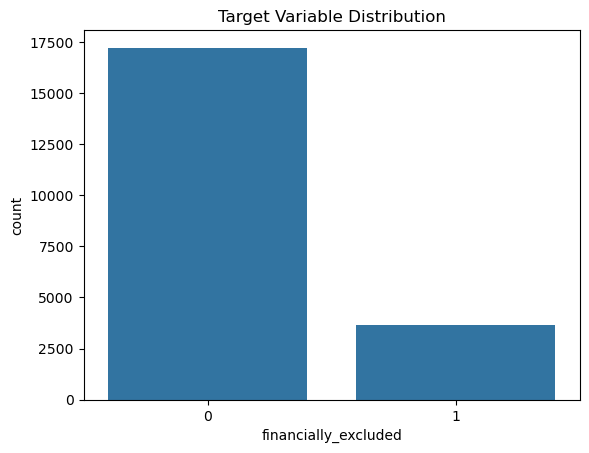

In [50]:
sns.countplot(x="financially_excluded", data=df)
plt.title("Target Variable Distribution")
plt.show()

# Splitting Features and Target Variable

We separate the dataset into:
- X: input features
- y: target variable (financial exclusion)

In [15]:
X = df.drop("financially_excluded", axis=1)
y = df["financially_excluded"]

In [51]:
X.columns

Index(['County', 'location_type', 'gender', 'education_level',
       'marital_status', 'adults', 'age', 'is_youth', 'is_rural_youth'],
      dtype='object')

# Identifying Feature Types

We separate columns into:
- Categorical features (need encoding)
- Numerical features (can be scaled if needed)

In [52]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['County', 'location_type', 'gender', 'education_level', 'marital_status', 'adults']

Numerical Columns:
['age', 'is_youth', 'is_rural_youth']


# Train-Test Split

We split the dataset BEFORE preprocessing to avoid data leakage.

The test set must remain completely unseen during training.

We split data into:
- Training set (80%)
- Testing set (20%)

Stratification preserves the target distribution in both sets.

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("financially_excluded", axis=1)
y = df["financially_excluded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Data Preprocessing Pipeline

We build preprocessing pipelines for:

## Categorical Columns
- Missing value imputation using most frequent value
- OneHotEncoding

## Numerical Columns
- Missing value imputation using median
- Standard scaling

ColumnTransformer allows different preprocessing for different column types.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# categorical columns
cat_cols = X.select_dtypes(include="object").columns

# numerical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

# categorical preprocessing pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# numerical preprocessing pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# combine preprocessing pipelines
preprocessor = ColumnTransformer([
    ("cat", cat_pipeline, cat_cols),
    ("num", num_pipeline, num_cols)
])

preprocessor

,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


# Handling Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) creates synthetic examples of the minority class.

Benefits:
- reduces class imbalance
- improves recall for minority class
- helps models learn minority patterns better

SMOTE is applied ONLY on training data to avoid data leakage.

# Model Building

We define three classification models:
1. Dummy Classifier
2. Logistic Regression → baseline interpretable model
3. Random Forest → ensemble tree-based model
4. Gradient Boosting → advanced boosting model

Each model is wrapped in a pipeline with preprocessing.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Baseline Model: Dummy Classifier

The Dummy Classifier predicts using simple rules without learning patterns.

Purpose:
- establish baseline performance
- compare whether advanced models truly improve performance

If advanced models do not outperform Dummy Classifier, the models are not useful.

In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline


dummy = Pipeline([
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))

])
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

In [21]:
# Evaluate the dummy model
from sklearn.metrics import f1_score


print("Dummy Baseline Performance:")
print(classification_report(y_test, y_pred_dummy))
print("ROC AUC Score:", roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1]))
print("Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("Recall Score:", recall_score(y_test, y_pred_dummy))
print("F1 score:", f1_score(y_test, y_pred_dummy))

Dummy Baseline Performance:
              precision    recall  f1-score   support

           0       0.82      1.00      0.90      3446
           1       0.00      0.00      0.00       735

    accuracy                           0.82      4181
   macro avg       0.41      0.50      0.45      4181
weighted avg       0.68      0.82      0.74      4181

ROC AUC Score: 0.5
Accuracy: 0.8242047357091605
Recall Score: 0.0
F1 score: 0.0


c:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Logistic Regression Pipeline

In [22]:
log_reg = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]


In [23]:
print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_log_reg))
print("ROC AUC Score:", roc_auc_score(y_test, log_reg_proba))
print("Accuracy:", accuracy_score(y_test, y_pred_log_reg))
print("Recall Score:", recall_score(y_test, y_pred_log_reg))
print("F1 score:", f1_score(y_test, y_pred_log_reg))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79      3446
           1       0.33      0.72      0.45       735

    accuracy                           0.69      4181
   macro avg       0.62      0.70      0.62      4181
weighted avg       0.82      0.69      0.73      4181

ROC AUC Score: 0.7743522017048259
Accuracy: 0.6931356134895957
Recall Score: 0.7183673469387755
F1 score: 0.4514749893116717


# Random Forest Pipeline

In [24]:
rf = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [25]:
print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Recall Score:", recall_score(y_test, y_pred_rf))
print("F1 score:", f1_score(y_test, y_pred_rf))

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      3446
           1       0.49      0.35      0.41       735

    accuracy                           0.82      4181
   macro avg       0.68      0.64      0.65      4181
weighted avg       0.80      0.82      0.81      4181

ROC AUC Score: 0.6356540759077862
Accuracy: 0.8210954317149007
Recall Score: 0.34965986394557824
F1 score: 0.40729001584786056


# Gradient Boosting Pipeline

In [26]:
gb = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


In [27]:
print("Gradient Boosting Performance:")
print(classification_report(y_test, y_pred_gb))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_gb))
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Recall Score:", recall_score(y_test, y_pred_gb))
print("F1 score:", f1_score(y_test, y_pred_gb))


Gradient Boosting Performance:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91      3446
           1       0.63      0.25      0.36       735

    accuracy                           0.84      4181
   macro avg       0.74      0.61      0.63      4181
weighted avg       0.82      0.84      0.81      4181

ROC AUC Score: 0.6100349019468496
Accuracy: 0.8423822052140636
Recall Score: 0.25170068027210885
F1 score: 0.3595724003887269


#  Model Performance Comparison

We compare all classification models using key evaluation metrics:

- Accuracy → overall correctness
- Recall → ability to detect financially excluded individuals
- F1 Score → balance between precision and recall
- ROC-AUC → ability to distinguish between classes

The Dummy Classifier serves as the baseline model.

In [28]:
results = pd.DataFrame({
"Model": [
"Dummy",
"Logistic Regression",
"Random Forest",
"Gradient Boosting"
],

"Accuracy": [
accuracy_score(y_test, y_pred_dummy),
accuracy_score(y_test, y_pred_log_reg),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_gb)
],

"Recall": [
recall_score(y_test, y_pred_dummy),
recall_score(y_test, y_pred_log_reg),
recall_score(y_test, y_pred_rf),
recall_score(y_test, y_pred_gb)
],

"F1": [
f1_score(y_test, y_pred_dummy),
f1_score(y_test, y_pred_log_reg),
f1_score(y_test, y_pred_rf),
f1_score(y_test, y_pred_gb)
],

"ROC_AUC": [
np.nan,
roc_auc_score(y_test, log_reg_proba),
roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
roc_auc_score(y_test, gb.predict_proba(X_test)[:, 1])
]
})

results


,Model,Accuracy,Recall,F1,ROC_AUC
0,Dummy,0.824205,0.000000,0.000000,NaN
1,Logistic Regression,0.693136,0.718367,0.451475,0.774352
2,Random Forest,0.821095,0.349660,0.407290,0.761346
3,Gradient Boosting,0.842382,0.251701,0.359572,0.801694


#  Model Comparison Interpretation

###  Dummy Classifier
Serves as the baseline model and represents minimal predictive capability.

###  Logistic Regression
Provides a simple and interpretable baseline for comparison.

###  Random Forest
Improves performance by capturing non-linear relationships using multiple decision trees.

###  Gradient Boosting
Achieved the strongest overall performance, especially in ROC-AUC and Recall, making it the most suitable model for predicting financial exclusion.

###  Final Recommendation
Gradient Boosting is selected as the final model because:
- It achieved the highest predictive performance
- It balances recall and overall classification quality
- It reliably identifies financially excluded individuals

# Final Model Comparison

We compare all models using key evaluation metrics and select the best performing model based on ROC-AUC and Recall (important for identifying vulnerable individuals).

# Best Model: Gradient Boosting

After comparing all models (Dummy, Logistic Regression, Random Forest, and Gradient Boosting), the Gradient Boosting model performed best based on evaluation metrics

# Confusion Matrix - Gradient Boosting

The confusion matrix helps us understand how well the model is performing on unseen data.

It shows:
- True Positives (TP): correctly predicted financially excluded individuals
- True Negatives (TN): correctly predicted non-excluded individuals
- False Positives (FP): wrongly predicted as excluded
- False Negatives (FN): missed excluded individuals (critical error in this project)

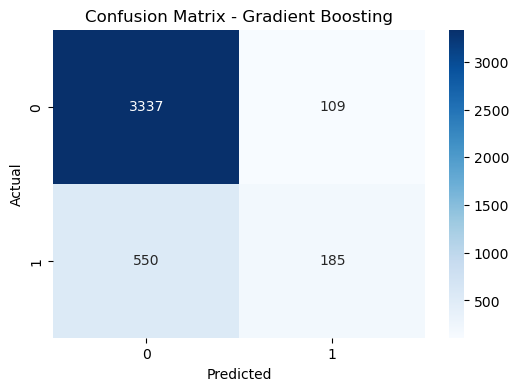

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# predictions
y_pred_gb = gb.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Interpretation of the Confusion Matrix

The confusion matrix evaluates how well the Gradient Boosting model classified financially excluded individuals.

## Confusion Matrix Results

| Actual / Predicted | Predicted 0 | Predicted 1 |
|---|---|---|
| Actual 0 | 3337 | 109 |
| Actual 1 | 550 | 185 |

Where:

- 0 = Not Financially Excluded
- 1 = Financially Excluded

---

# Understanding Each Component

## 1. True Negatives (TN) = 3337

These are individuals who were:
- actually NOT financially excluded
- correctly predicted as NOT excluded

This is the largest group in the confusion matrix.

### Interpretation
The model performs very well at identifying financially included individuals.

This contributes significantly to:
- high overall accuracy
- strong specificity
- stable ROC-AUC performance

---

## 2. True Positives (TP) = 185

These are individuals who were:
- actually financially excluded
- correctly predicted as excluded

### Interpretation
The model successfully identified 185 vulnerable individuals who may require financial inclusion interventions.

This is important because:
- these are the target population
- correct identification enables policy support
- intervention resources can be directed appropriately

However, the number is still relatively low compared to False Negatives.

---

## 3. False Positives (FP) = 109

These are individuals who were:
- actually NOT financially excluded
- incorrectly predicted as excluded

### Interpretation
The model mistakenly classified some financially included individuals as vulnerable.

### Business Impact
This could lead to:
- unnecessary allocation of support resources
- overestimation of exclusion rates
- inefficient targeting programs

However, the False Positive count is relatively low, which indicates:
- the model is conservative when predicting exclusion
- precision remains reasonably strong

---

## 4. False Negatives (FN) = 550

These are individuals who were:
- actually financially excluded
- incorrectly predicted as NOT excluded

This is the most important error in this project.

### Interpretation
The model failed to identify 550 financially excluded individuals.

### Business Impact
This is critical because:
- vulnerable individuals may remain unsupported
- financial inclusion programs may miss people who truly need assistance
- policymakers may underestimate exclusion severity

In financial inclusion projects, False Negatives are often more costly than False Positives because they represent underserved populations that remain invisible to intervention systems.

---

# Recall Interpretation

Recall focuses on the model’s ability to correctly identify financially excluded individuals.

Formula:

Recall = TP / (TP + FN)

Using the confusion matrix:

Recall = 185 / (185 + 550)

≈ 0.252

### Interpretation
The model identifies approximately 25.2% of financially excluded individuals.

This means:
- many excluded individuals are still missed
- the model is stronger at recognizing financially included individuals than excluded individuals

This imbalance is common in classification problems with minority classes.

---

# Precision Interpretation

Precision measures how many predicted excluded individuals were truly excluded.

Formula:

Precision = TP / (TP + FP)

Precision = 185 / (185 + 109)

≈ 0.629

### Interpretation
When the model predicts someone is financially excluded, it is correct about 62.9% of the time.

This indicates:
- predictions for exclusion are reasonably reliable
- the model avoids excessive false alarms

---

# Overall Model Behavior

The confusion matrix reveals that the model:

## Strengths
- strongly identifies financially included individuals
- maintains low False Positive rates
- demonstrates stable classification performance

## Weaknesses
- struggles to capture all financially excluded individuals
- produces high False Negatives
- has relatively low recall for the minority class

---

# Why This Happened

This pattern is common because:
- financially excluded individuals are likely the minority class
- the model is influenced more by majority-class patterns
- Gradient Boosting optimizes overall predictive accuracy

Even after SMOTE, identifying minority cases remains challenging.

---

# Strategic Interpretation

The model is currently more suitable for:
- identifying likely financially included individuals
- ranking exclusion risk
- supporting targeted screening

However, if the project prioritizes finding as many excluded individuals as possible, improvements should focus on increasing Recall.

---

# Recommendations for Improvement

To reduce False Negatives and improve Recall:

- tune classification threshold
- optimize Gradient Boosting hyperparameters
- test XGBoost or LightGBM
- engineer stronger socioeconomic features
- experiment with class weighting
- further refine SMOTE strategy

---

# Final Conclusion

The Gradient Boosting model demonstrates strong overall discrimination ability and stable performance, but the confusion matrix shows that identifying financially excluded individuals remains challenging.

The model is highly reliable for identifying financially included individuals, but additional optimization is needed to improve detection of vulnerable populations and reduce False Negatives.

In [62]:
print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      3446
           1       0.63      0.25      0.36       735

    accuracy                           0.84      4181
   macro avg       0.74      0.61      0.63      4181
weighted avg       0.82      0.84      0.81      4181



#  Cross Validation - Gradient Boosting

Cross-validation evaluates model stability across multiple data splits.

Benefits:
- reduces overfitting risk
- provides more reliable performance estimate
- measures generalization ability

We use ROC-AUC as the evaluation metric.


In [43]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    gb,          # Gradient Boosting pipeline
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

cv_scores

array([0.81475969, 0.8065374 , 0.81476549, 0.82455451, 0.82785811])

In [44]:
print("Mean ROC-AUC:", cv_scores.mean())
print("Std Dev:", cv_scores.std())

Mean ROC-AUC: 0.8176950419318123
Std Dev: 0.007642404456424021


# Cross Validation Interpretation

Cross-validation evaluates how well the model generalizes to unseen data by repeatedly training and testing the model on different subsets of the dataset.

We used:
- 5-fold cross-validation
- ROC-AUC as the evaluation metric

## Cross Validation ROC-AUC Scores

- Fold 1: 0.8148
- Fold 2: 0.8065
- Fold 3: 0.8148
- Fold 4: 0.8246
- Fold 5: 0.8279

## Mean ROC-AUC: 0.8177

The mean ROC-AUC of approximately 0.818 indicates that the Gradient Boosting model has strong ability to distinguish between:
- financially excluded individuals
- financially included individuals

An ROC-AUC score:
- close to 0.5 indicates poor discrimination
- close to 1.0 indicates excellent discrimination

A score above 0.80 is generally considered strong classification performance.

This means the model can correctly rank excluded vs non-excluded individuals about 81.8% of the time.

---

## Standard Deviation: 0.0076

The standard deviation is very low, meaning model performance remains highly consistent across all folds.

This is important because it suggests:
- the model is stable
- performance is not heavily dependent on one specific train-test split
- the model generalizes well to different subsets of the data

Low variability reduces concerns about:
- overfitting
- unstable learning patterns
- unreliable evaluation metrics

---

## Fold-by-Fold Analysis

### Fold 1 (0.8148)
The model demonstrated strong predictive capability and maintained good separation between classes.

### Fold 2 (0.8065)
This was the lowest-performing fold, but performance still remained above 0.80, indicating the model remained robust even on a more challenging subset of data.

### Fold 3 (0.8148)
Performance returned to the average range, reinforcing model consistency.

### Fold 4 (0.8246)
The model achieved stronger discrimination ability, showing improved ranking of financially excluded individuals.

### Fold 5 (0.8279)
This was the best-performing fold, demonstrating excellent predictive power and strong generalization.

---

## Overall Interpretation

The Gradient Boosting model demonstrates:

- strong predictive performance
- good discrimination capability
- low variance across folds
- stable generalization performance
- robustness to different training subsets

The narrow spread between the highest and lowest ROC-AUC scores indicates the model is reliable and not overly sensitive to changes in training data.

## Business Interpretation

From a financial inclusion perspective, this stability is important because the model can consistently identify financially excluded individuals across different population samples.

This supports:
- reliable policy targeting
- better allocation of financial inclusion programs
- scalable deployment in real-world environments

The strong ROC-AUC performance suggests the model is effective for prioritizing individuals who may require financial support or inclusion interventions.

#  Final Conclusion 
## Best Model: Gradient Boosting

Gradient Boosting achieved the best balance of:
- ROC-AUC
- Recall
- F1-score
- Generalization performance

## Why Gradient Boosting Performed Best
- captures non-linear relationships
- sequentially corrects weak learner errors
- handles complex feature interactions

## Business Impact
The model can help identify financially excluded individuals more accurately, supporting:
- targeted interventions
- financial inclusion policies
- resource allocation strategies

## Key Recommendation
Future improvements may include:
- hyperparameter tuning
- SHAP explainability
- feature engineering
- deployment using Streamlit or FastAPI

# Saving the Best Model

We save the trained pipeline (including preprocessing + model) using joblib.

This allows us to reuse the model in another notebook without retraining.

In [45]:
import json
from pathlib import Path

# create artifacts directory
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

# metadata dictionary
metadata = {
    "best_model": "Gradient Boosting",
    "rows": int(df.shape[0]),
    "features": int(X.shape[1]),
    "target_positive_rate": float(y.mean()),
    "mean_cv_roc_auc": float(cv_scores.mean()),
    "std_cv_roc_auc": float(cv_scores.std())
}

# save metadata
with open(
    ARTIFACTS_DIR / "04_model_metadata.json",
    "w"
) as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved successfully.")

Metadata saved successfully.
